In [1]:
# QUICKCART STOCKOUT RISK PREDICTION
# Machine Learning Classification Project

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

Load Dataset

In [2]:
stores = pd.read_csv("dim_stores.csv")
skus = pd.read_csv("dim_skus.csv")
suppliers = pd.read_csv("dim_suppliers.csv")
events = pd.read_csv("dim_events.csv")
inventory = pd.read_csv("fact_inventory_daily.csv")

print("Stores:", stores.shape)
print("SKUs:", skus.shape)
print("Suppliers:", suppliers.shape)
print("Events:", events.shape)
print("Inventory:", inventory.shape)

Stores: (12, 8)
SKUs: (60, 9)
Suppliers: (15, 6)
Events: (30, 5)
Inventory: (21600, 16)


View Inventory Data

In [3]:
inventory.head()

,date,store_id,sku_id,supplier_id,opening_stock,units_demanded,units_sold,closing_stock,reorder_point,reorder_placed,lead_time_days_expected,lead_time_days_actual,sales_velocity_7d,days_of_cover,is_festival_week,stockout_risk
0,2026-10-01,ST01,SKU001,SUP11,159.9,15,15.0,144.9,36.4,N,1,NaN,15.00,9.66,N,Safe
1,2026-10-02,ST01,SKU001,SUP11,144.9,10,10.0,134.9,36.4,N,1,NaN,12.50,10.79,N,Safe
2,2026-10-03,ST01,SKU001,SUP11,134.9,15,15.0,119.9,36.4,N,1,NaN,13.33,8.99,N,Safe
3,2026-10-04,ST01,SKU001,SUP11,119.9,10,10.0,109.9,36.4,N,1,NaN,12.50,8.79,N,Safe
4,2026-10-05,ST01,SKU001,SUP11,109.9,9,9.0,100.9,36.4,N,1,NaN,11.80,8.55,N,Safe


Check Columns

In [4]:
inventory.columns

Index(['date', 'store_id', 'sku_id', 'supplier_id', 'opening_stock',
       'units_demanded', 'units_sold', 'closing_stock', 'reorder_point',
       'reorder_placed', 'lead_time_days_expected', 'lead_time_days_actual',
       'sales_velocity_7d', 'days_of_cover', 'is_festival_week',
       'stockout_risk'],
      dtype='object')

Check Stockout Classes

In [5]:
inventory["stockout_risk"].value_counts()

,count
stockout_risk,
Safe,14131
At-Risk,5186
Imminent,2283


In [6]:
print(inventory["stockout_risk"].value_counts(normalize=True) * 100)

stockout_risk
Safe        65.421296
At-Risk     24.009259
Imminent    10.569444
Name: proportion, dtype: float64


Check Missing Values

In [7]:
print(stores.isnull().sum())
print(skus.isnull().sum())
print(suppliers.isnull().sum())
print(events.isnull().sum())
print(inventory.isnull().sum())

store_id                 0
city                     0
city_display             0
city_tier                0
store_size               0
sqft                     0
opened_year              0
baseline_daily_orders    0
dtype: int64
sku_id              0
sku_name            0
category            0
unit_price_inr      0
shelf_life_days     0
is_perishable       0
festive_relevant    0
popularity_tier     0
supplier_id         0
dtype: int64
supplier_id                0
supplier_name              0
categories_supplied        0
reliability_score          3
base_lead_time_days        0
lead_time_variance_days    0
dtype: int64
date                         0
event_name                   0
event_type                   0
demand_multiplier_festive    0
demand_multiplier_other      0
dtype: int64
date                           0
store_id                       0
sku_id                         0
supplier_id                    0
opening_stock                  0
units_demanded                 0
units_s

Clean Supplier Reliability

In [27]:
suppliers["reliability_score"] = pd.to_numeric(
    suppliers["reliability_score"],
    errors="coerce"
)

suppliers["reliability_score"] = suppliers[
    "reliability_score"
].fillna(
    suppliers["reliability_score"].median()
)

Clean City Names

In [9]:
stores["city_display"] = (
    stores["city_display"]
    .str.strip()
    .str.title()
)

Merge Datasets

In [10]:
df = inventory.merge(
    skus,
    on="sku_id",
    how="left"
)

df = df.merge(
    suppliers,
    left_on="supplier_id_x",
    right_on="supplier_id",
    how="left"
)

df = df.merge(
    stores,
    on="store_id",
    how="left"
)

events["date"] = pd.to_datetime(events["date"])
df["date"] = pd.to_datetime(df["date"])

df = df.merge(
    events,
    on="date",
    how="left"
)

print(df.shape)

(21600, 41)


View Final Dataset

In [11]:
df.head()

,date,store_id,sku_id,supplier_id_x,opening_stock,units_demanded,units_sold,closing_stock,reorder_point,reorder_placed,...,city_display,city_tier,store_size,sqft,opened_year,baseline_daily_orders,event_name,event_type,demand_multiplier_festive,demand_multiplier_other
0,2026-10-01,ST01,SKU001,SUP11,159.9,15,15.0,144.9,36.4,N,...,Mumbai,Tier1,Large,2946,2023,580,Regular Day,none,1.0,1.0
1,2026-10-02,ST01,SKU001,SUP11,144.9,10,10.0,134.9,36.4,N,...,Mumbai,Tier1,Large,2946,2023,580,Regular Day,none,1.0,1.0
2,2026-10-03,ST01,SKU001,SUP11,134.9,15,15.0,119.9,36.4,N,...,Mumbai,Tier1,Large,2946,2023,580,Regular Day,none,1.0,1.0
3,2026-10-04,ST01,SKU001,SUP11,119.9,10,10.0,109.9,36.4,N,...,Mumbai,Tier1,Large,2946,2023,580,Regular Day,none,1.0,1.0
4,2026-10-05,ST01,SKU001,SUP11,109.9,9,9.0,100.9,36.4,N,...,Mumbai,Tier1,Large,2946,2023,580,Regular Day,none,1.0,1.0


Feature Engineering

In [12]:
df["reorder_gap"] = (
    df["reorder_point"] -
    df["closing_stock"]
)
df["days_of_cover_ratio"] = (
    df["days_of_cover"] /
    df["lead_time_days_expected"]
)
df["day_of_month"] = df["date"].dt.day
df["month"] = df["date"].dt.month
df["day_of_week"] = df["date"].dt.dayofweek

Convert Yes/No Columns

In [13]:
df["is_festival_week"] = (
    df["is_festival_week"]
    .map({"Y": 1, "N": 0})
)
df["is_perishable"] = (
    df["is_perishable"]
    .map({"Y": 1, "N": 0})
)
df["festive_relevant"] = (
    df["festive_relevant"]
    .map({"Y": 1, "N": 0})
)

Stockout Visualization

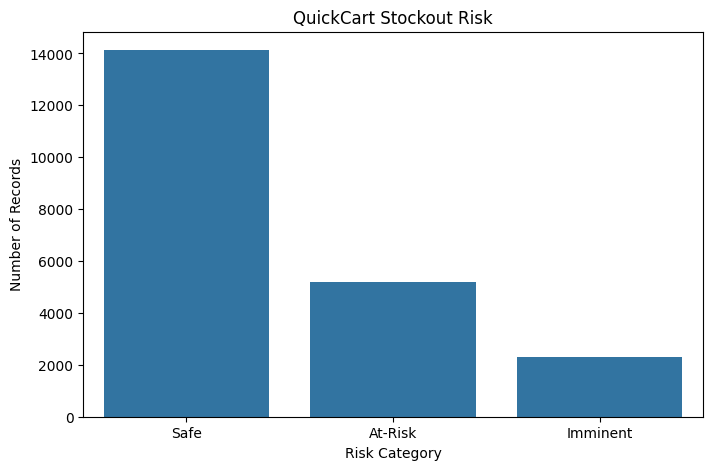

In [14]:
plt.figure(figsize=(8,5))
sns.countplot(data=df,x="stockout_risk")
plt.title("QuickCart Stockout Risk")
plt.xlabel("Risk Category")
plt.ylabel("Number of Records")
plt.show()

Feature Selection

In [15]:
features = [
    "opening_stock",
    "closing_stock",
    "units_demanded",
    "units_sold",
    "reorder_point",
    "lead_time_days_expected",
    "sales_velocity_7d",
    "days_of_cover",
    "reorder_gap",
    "days_of_cover_ratio",
    "day_of_month",
    "month",
    "day_of_week",
    "is_festival_week",
    "is_perishable",
    "festive_relevant",
    "reliability_score"
]
X = df[features]
y = df["stockout_risk"]

Handle Missing Values

In [16]:
X = X.fillna(X.median(numeric_only=True))

Train/Test Split

In [17]:
X_tr, X_te, y_tr, y_te = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

Random Forest

In [18]:
rf = RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(X_tr, y_tr)

RandomForestClassifier(random_state=42)

Prediction

In [19]:
y_pred = rf.predict(X_te)

Accuracy

In [20]:
print("Accuracy:",accuracy_score(y_te, y_pred))

Accuracy: 0.9467592592592593


Classification Report

In [21]:
print(classification_report(y_te,y_pred))

              precision    recall  f1-score   support

     At-Risk       0.86      0.93      0.89      1037
    Imminent       0.83      0.68      0.75       457
        Safe       1.00      1.00      1.00      2826

    accuracy                           0.95      4320
   macro avg       0.90      0.87      0.88      4320
weighted avg       0.95      0.95      0.95      4320



Confusion Matrix

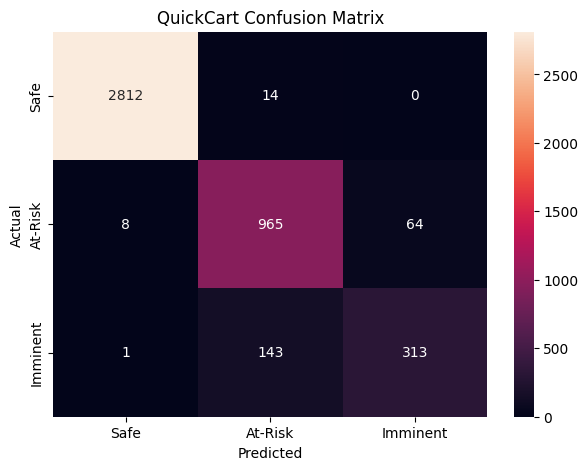

In [22]:
cm = confusion_matrix(y_te,y_pred,labels=["Safe", "At-Risk", "Imminent"])
plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Safe", "At-Risk", "Imminent"],
    yticklabels=["Safe", "At-Risk", "Imminent"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("QuickCart Confusion Matrix")
plt.show()

Feature Importance

In [23]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})
importance = importance.sort_values(
    "Importance",
    ascending=False
)
print(importance)

                    Feature  Importance
9       days_of_cover_ratio    0.286031
7             days_of_cover    0.258528
8               reorder_gap    0.198381
1             closing_stock    0.053557
6         sales_velocity_7d    0.033934
5   lead_time_days_expected    0.031600
0             opening_stock    0.025828
4             reorder_point    0.023377
16        reliability_score    0.021483
10             day_of_month    0.020042
3                units_sold    0.014887
2            units_demanded    0.014041
12              day_of_week    0.007682
15         festive_relevant    0.005150
14            is_perishable    0.003784
13         is_festival_week    0.001693
11                    month    0.000000


Visualize

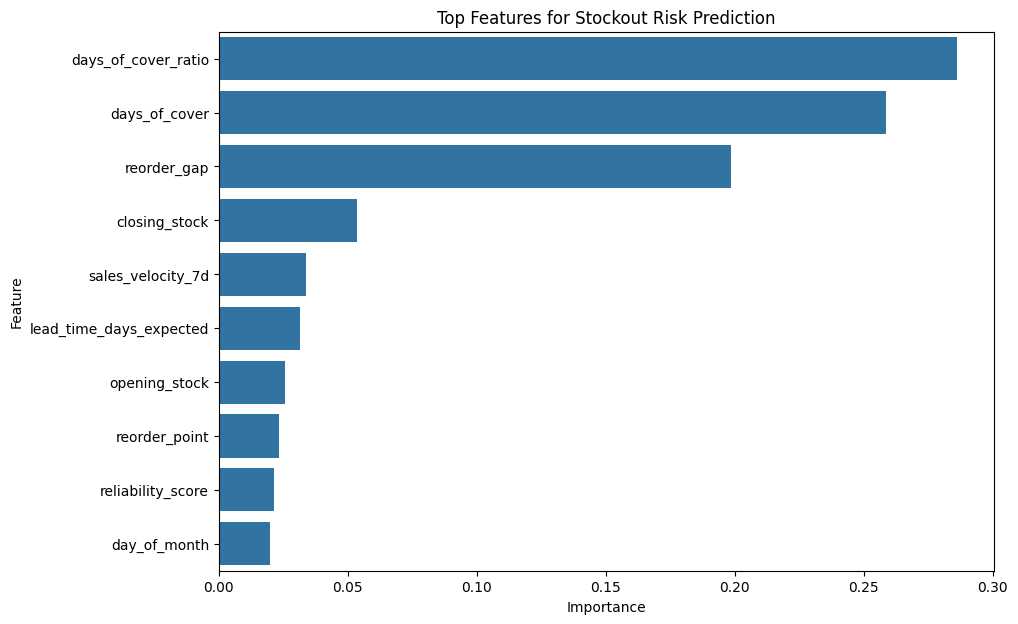

In [24]:
plt.figure(figsize=(10,7))
sns.barplot(data=importance.head(10),x="Importance",y="Feature")
plt.title("Top Features for Stockout Risk Prediction")
plt.show()

Final Prediction

In [25]:
sample = X_te.iloc[[0]]
prediction = rf.predict(sample)
print("Predicted Stockout Risk:", prediction[0])

Predicted Stockout Risk: Safe
